# Saudi Tourism Data Analysis

This notebook presents an exploratory data analysis (EDA) and data preparation process for a tourism dataset covering Saudi Arabia (2015–2024).

The goal is to understand tourism patterns, detect data issues, and prepare a clean dataset for further analysis and visualization in Power BI.

## Data Loading

The dataset is loaded using pandas to begin the analysis process.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

In [ ]:
df = pd.read_csv("tourism_data.csv")

## Initial Data Exploration

In this step, the dataset structure and content are explored:

- Previewing the first rows of the dataset  
- Understanding statistical summaries  
- Inspecting data types and structure  

This helps in identifying potential data quality issues early.

In [ ]:
df.head()

,YEARS,Tourists_Number,Overnight_Stay,Tourists_Spending,Avg_Stay,Avg_Spending_Trip,Avg_Spending_Night,Province,Tourism_Type
0,2015,6.0,59.0,43.0,10.0,7029.0,727.0,Albaha,Inbound
1,2015,6.0,59.0,43.0,10.0,7029.0,727.0,Albaha,Inbound
2,2015,0.0,0.0,0.0,0.0,0.0,0.0,Albaha,Inbound
3,2015,0.0,0.0,0.0,0.0,0.0,0.0,Albaha,Inbound
4,2015,1041.0,8807.0,1120.0,8.5,1075.0,127.0,Albaha,Domestic


In [ ]:
df.describe()

,YEARS,Tourists_Number,Overnight_Stay,Tourists_Spending,Avg_Stay,Avg_Spending_Trip,Avg_Spending_Night
count,1058.000000,1058.000000,1058.000000,1058.000000,1058.000000,1058.000000,1058.000000
mean,2019.522684,1470.101323,10752.581569,3415.744707,8.680340,2441.300567,351.426276
std,2.879799,3107.374042,32095.816028,12359.888247,9.183977,2343.430252,288.275322
min,2015.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2017.000000,29.000000,186.500000,63.000000,4.300000,1075.250000,170.000000
50%,2020.000000,269.500000,1662.000000,382.500000,6.100000,1595.500000,241.500000
75%,2022.000000,1265.050000,8896.250000,1871.750000,8.700000,3062.750000,441.000000
max,2024.000000,23487.000000,430796.000000,140770.000000,71.000000,39009.000000,1987.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1058 entries, 0 to 1057
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   YEARS               1058 non-null   int64  
 1   Tourists_Number     1058 non-null   float64
 2   Overnight_Stay      1058 non-null   float64
 3   Tourists_Spending   1058 non-null   float64
 4   Avg_Stay            1058 non-null   float64
 5   Avg_Spending_Trip   1058 non-null   float64
 6   Avg_Spending_Night  1058 non-null   float64
 7   Province            1058 non-null   object 
 8   Tourism_Type        1058 non-null   object 
dtypes: float64(6), int64(1), object(2)
memory usage: 74.5+ KB


## Categorical Analysis

This step explores categorical variables:

- Province distribution  
- Tourism type distribution (Domestic vs Inbound)  

This provides an overview of data coverage and category balance.

In [ ]:
df["Province"].value_counts()

,count
Province,
Makkah,118
Tabuk,111
Madinah,100
Eastern_region,100
Alqassim,100
Albaha,80
Aseer,80
Jouf,80
Riyadh,60


In [ ]:
df["Tourism_Type"].value_counts()

,count
Tourism_Type,
Domestic,540
Inbound,518


## Missing Values Check

The dataset is checked for missing values to ensure data completeness before further processing.

In [ ]:
df.isnull().sum()

,0
YEARS,0
Tourists_Number,0
Overnight_Stay,0
Tourists_Spending,0
Avg_Stay,0
Avg_Spending_Trip,0
Avg_Spending_Night,0
Province,0
Tourism_Type,0


## Data Structure Overview

This step reviews:

- Column names  
- Number of features  
- Dataset shape  

To confirm consistency and readiness for cleaning.

In [ ]:
df.columns

Index(['YEARS', 'Tourists_Number', 'Overnight_Stay', 'Tourists_Spending',
       'Avg_Stay', 'Avg_Spending_Trip', 'Avg_Spending_Night', 'Province',
       'Tourism_Type'],
      dtype='object')

In [ ]:
df.shape

(1058, 9)

## Duplicate Records Handling

Duplicate rows are identified and removed to improve data quality and avoid biased analysis.

In [ ]:
df.duplicated().sum()

np.int64(28)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.duplicated().sum()

np.int64(0)

## Unique Values Analysis

This step examines the number of unique values in each column to better understand data variability and cardinality.

In [ ]:
df.nunique()

,0
YEARS,10
Tourists_Number,692
Overnight_Stay,865
Tourists_Spending,726
Avg_Stay,220
Avg_Spending_Trip,870
Avg_Spending_Night,517
Province,13
Tourism_Type,2


## Outlier Detection

A boxplot is used to detect outliers in the number of tourists.

This helps identify extreme values that may affect analysis results.

{'whiskers': [<matplotlib.lines.Line2D at 0x7f47ca8e1cd0>,
 'caps': [<matplotlib.lines.Line2D at 0x7f47ca8e16a0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7f47ca8e2000>],
 'medians': [<matplotlib.lines.Line2D at 0x7f47ca8e10a0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7f47ca8e0da0>],
 'means': []}

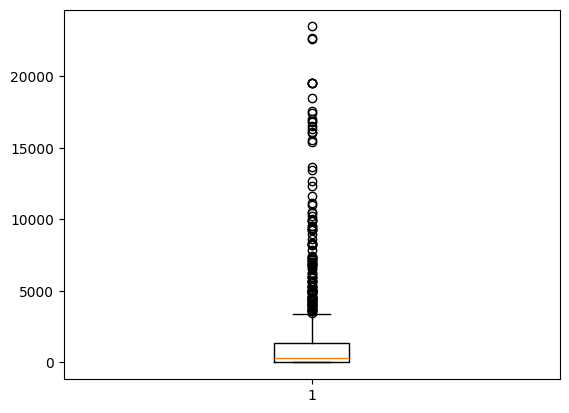

In [ ]:
plt.boxplot(df['Tourists_Number'])

## Aggregation by Province

Tourist numbers are aggregated by province to identify high-performing regions.

This provides insights into regional tourism distribution.

In [ ]:
df.groupby("Province")["Tourists_Number"].sum().sort_values(ascending= False)

,Tourists_Number
Province,
Makkah,616608.9
Riyadh,229132.5
Eastern_region,213412.5
Madinah,136439.6
Aseer,112690.6
Alqassim,50944.7
Jazan,49524.0
Tabuk,41738.2
Hail,25465.4


## Correlation Analysis

A correlation matrix is generated to examine relationships between numerical variables.

This helps identify strong relationships such as:
- Tourism spending and overnight stays  
- Tourist numbers and total spending  

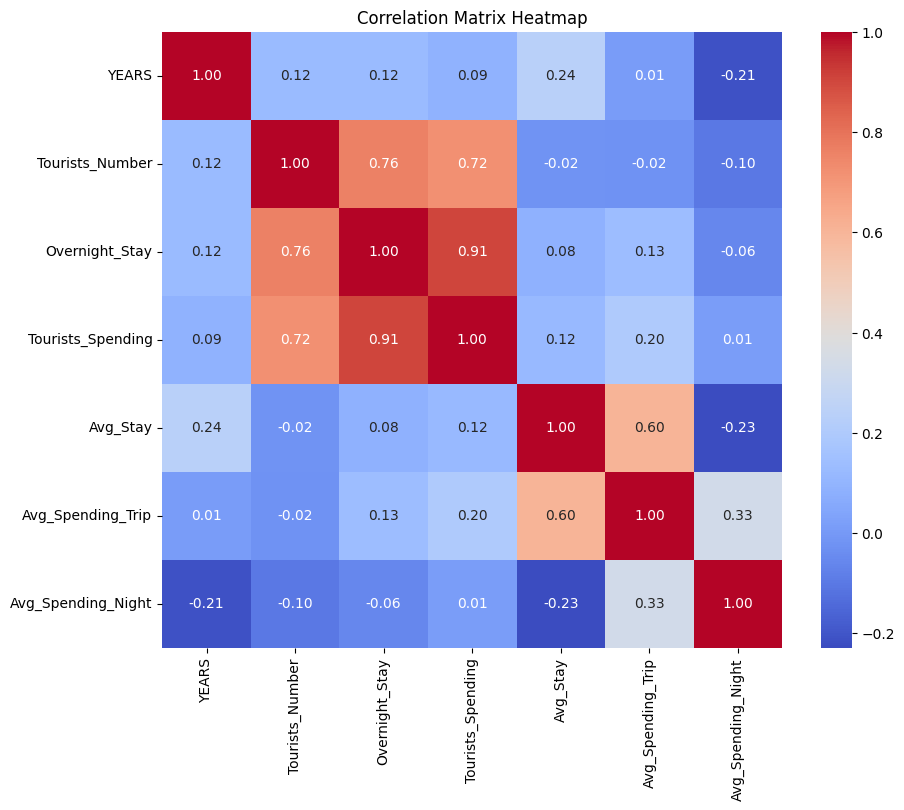

In [ ]:
import seaborn as sns
correlation_matrix = df.corr(numeric_only=True) # Define correlation_matrix here
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()

In [ ]:
df.corr(numeric_only=True)

,YEARS,Tourists_Number,Overnight_Stay,Tourists_Spending,Avg_Stay,Avg_Spending_Trip,Avg_Spending_Night
YEARS,1.000000,0.121641,0.123515,0.088073,0.235920,0.008488,-0.213246
Tourists_Number,0.121641,1.000000,0.762777,0.718574,-0.022292,-0.023897,-0.099580
Overnight_Stay,0.123515,0.762777,1.000000,0.907305,0.084781,0.132124,-0.057417
Tourists_Spending,0.088073,0.718574,0.907305,1.000000,0.117619,0.199917,0.014060
Avg_Stay,0.235920,-0.022292,0.084781,0.117619,1.000000,0.602747,-0.228792
Avg_Spending_Trip,0.008488,-0.023897,0.132124,0.199917,0.602747,1.000000,0.331129
Avg_Spending_Night,-0.213246,-0.099580,-0.057417,0.014060,-0.228792,0.331129,1.000000


## Feature Engineering

New features are created to enhance analysis:

- Spending per Tourist  
- Stay per Tourist  
- Spending per Night  

Division by zero is handled to ensure data accuracy.

In [ ]:
df["Spending_per_Tourist"] = np.where(
    df["Tourists_Number"] == 0, np.nan,
    df["Tourists_Spending"] / df["Tourists_Number"])

In [ ]:
df["Stay_per_Tourist"] = np.where(
    df["Tourists_Number"] == 0 , np.nan,
  df["Overnight_Stay"] / df["Tourists_Number"])

In [ ]:
df.columns

Index(['YEARS', 'Tourists_Number', 'Overnight_Stay', 'Tourists_Spending',
       'Avg_Stay', 'Avg_Spending_Trip', 'Avg_Spending_Night', 'Province',
       'Tourism_Type', 'Spending_per_Tourist', 'Stay_per_Tourist'],
      dtype='object')

In [ ]:
df["Spanding_per_Night"] = df["Tourists_Spending"] / df["Overnight_Stay"]

## COVID-19 Period Classification

A new column is created to classify years into:

- COVID period (2020–2021)  
- Normal period  

This supports impact analysis of the pandemic.

In [ ]:
df["Covid_Period"] = df['YEARS'].apply(lambda x : 'COVID' if x in [2020,2021] else "Normal")

## Data Validation

The dataset is rechecked after transformations to ensure:

- Correct data types  
- No unexpected missing values  
- Successful feature creation  

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1030 entries, 0 to 1057
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   YEARS                 1030 non-null   int64  
 1   Tourists_Number       1030 non-null   float64
 2   Overnight_Stay        1030 non-null   float64
 3   Tourists_Spending     1030 non-null   float64
 4   Avg_Stay              1030 non-null   float64
 5   Avg_Spending_Trip     1030 non-null   float64
 6   Avg_Spending_Night    1030 non-null   float64
 7   Province              1030 non-null   object 
 8   Tourism_Type          1030 non-null   object 
 9   Spending_per_Tourist  1019 non-null   float64
 10  Stay_per_Tourist      1019 non-null   float64
 11  Spanding_per_Night    1020 non-null   float64
 12  Covid_Period          1030 non-null   object 
dtypes: float64(9), int64(1), object(3)
memory usage: 112.7+ KB


In [ ]:
df.isnull().sum()

,0
YEARS,0
Tourists_Number,0
Overnight_Stay,0
Tourists_Spending,0
Avg_Stay,0
Avg_Spending_Trip,0
Avg_Spending_Night,0
Province,0
Tourism_Type,0
Spending_per_Tourist,11


## Export Cleaned Data

The cleaned dataset is exported for use in Power BI dashboard development.

In [ ]:
df.to_csv("cleaned_tourism.csv" , index = False)